In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/MoNuSAC_images_and_annotations


/content/drive/MyDrive/MoNuSAC_images_and_annotations


In [3]:
!pip install torch
!pip install openslide-python
!pip install openslide-bin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 40.3 MB/s eta 0:00:00


In [4]:

import os
import pandas as pd
import cv2
from sklearn.model_selection import train_test_split
import torch
from torchvision import transforms
from PIL import Image
import numpy as np
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from matplotlib import pyplot as plt
import openslide
from xml.dom import minidom
from openslide import open_slide
from glob import glob
import scipy.io as sio
import scipy.ndimage
import scipy
from shapely.geometry import Polygon
from skimage import draw
import xml.etree.ElementTree as ET

In [3]:
# Reading svs files from the desired path
count = 0
data_path = '/content/drive/MyDrive/MoNuSAC_images_and_annotations' # Path to read data from
destination_path = '/content/drive/MyDrive/' # Path to save n-ary masks corresponding to xml files
os.chdir(destination_path)

try:
    os.mkdir(destination_path+'\MoNuSAC_masks')
except OSError:
    print ("Creation of the mask directory %s failed" % destination_path)

os.chdir(destination_path+'\MoNuSAC_masks') # Creating folder named as MoNuSAC_masks
patients = [x[0] for x in os.walk(data_path)] # Total patients in the data_path
len(patients)

<>:8: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
<>:8: SyntaxWarning: invalid escape sequence '\M'
<>:12: SyntaxWarning: invalid escape sequence '\M'
/tmp/ipython-input-1295011943.py:8: SyntaxWarning: invalid escape sequence '\M'
  os.mkdir(destination_path+'\MoNuSAC_masks')
/tmp/ipython-input-1295011943.py:12: SyntaxWarning: invalid escape sequence '\M'
  os.chdir(destination_path+'\MoNuSAC_masks') # Creating folder named as MoNuSAC_masks


Creation of the mask directory /content/drive/MyDrive/ failed


47

In [ ]:
for patient_loc in patients:
    patient_name = patient_loc[len(data_path)+1:]#Patient name
    print(patient_name)

    ## To make patient's name directory in the destination folder
    try:
        os.mkdir(patient_name)
    except OSError:
        print ("\n Creation of the patient's directory %s failed" % patient_name)

    ## Read sub-images of each patient in the data path
    sub_images = glob(patient_loc+'/*.svs')
    for sub_image_loc in sub_images:
        gt = 0
        sub_image_name = sub_image_loc[len(data_path)+len(patient_name)+1:-4]
        print(sub_image_name)

        ## To make sub_image directory under the patient's folder
        sub_image = './'+patient_name+'/'+sub_image_name #Destination path
        try:
            os.mkdir(sub_image)
        except OSError:
            print ("\n Creation of the patient's directory %s failed" % sub_image)

        image_name = sub_image_loc
        img = openslide.OpenSlide(image_name)

        # If svs image needs to save in tif
        cv2.imwrite(sub_image_loc[:-4]+'.tif', np.array(img.read_region((0,0),0,img.level_dimensions[0])))

        # Read xml file
        xml_file_name  = image_name[:-4]
        xml_file_name = xml_file_name+'.xml'
        tree = ET.parse(xml_file_name)
        root = tree.getroot()

        #Generate n-ary mask for each cell-type
        for k in range(len(root)):
            label = [x.attrib['Name'] for x in root[k][0]]
            label = label[0]

            for child in root[k]:
                for x in child:
                    r = x.tag
                    if r == 'Attribute':
                        count = count+1
                        print(count)
                        label = x.attrib['Name']
                        n_ary_mask = np.transpose(np.zeros((img.read_region((0,0),0,img.level_dimensions[0]).size)))
                        print(label)

                        # Create directory for each label
                        sub_path = sub_image+'/'+label

                        try:
                            os.mkdir(sub_path)
                        except OSError:
                            print ("Creation of the directory %s failed" % label)
                        else:
                            print ("Successfully created the directory %s " % label)


                    if r == 'Region':
                        regions = []
                        vertices = x[1]
                        coords = np.zeros((len(vertices), 2))
                        for i, vertex in enumerate(vertices):
                            coords[i][0] = vertex.attrib['X']
                            coords[i][1] = vertex.attrib['Y']
                        regions.append(coords)
                        poly = Polygon(regions[0])

                        vertex_row_coords = regions[0][:,0]
                        vertex_col_coords = regions[0][:,1]
                        fill_row_coords, fill_col_coords = draw.polygon(vertex_col_coords, vertex_row_coords, n_ary_mask.shape)
                        gt = gt+1 #Keep track of giving unique valu to each instance in an image
                        n_ary_mask[fill_row_coords, fill_col_coords] = gt
                        mask_path = sub_path+'/'+str(count)+'_mask.tif'
                        cv2.imwrite(mask_path, n_ary_mask)



 Creation of the patient's directory  failed
TCGA-55-1594-01Z-00-DX1
/TCGA-55-1594-01Z-00-DX1_005
1
Epithelial
Successfully created the directory Epithelial 
2
Lymphocyte
Successfully created the directory Lymphocyte 
3
Neutrophil
Successfully created the directory Neutrophil 
4
Macrophage
Successfully created the directory Macrophage 
/TCGA-55-1594-01Z-00-DX1_001
5
Epithelial
Successfully created the directory Epithelial 
6
Lymphocyte
Successfully created the directory Lymphocyte 
7
Neutrophil
Successfully created the directory Neutrophil 
8
Macrophage
Successfully created the directory Macrophage 
/TCGA-55-1594-01Z-00-DX1_003
9
Epithelial
Successfully created the directory Epithelial 
10
Lymphocyte
Successfully created the directory Lymphocyte 
11
Neutrophil
Successfully created the directory Neutrophil 
12
Macrophage
Successfully created the directory Macrophage 
/TCGA-55-1594-01Z-00-DX1_002
13
Epithelial
Successfully created the directory Epithelial 
14
Lymphocyte
Successfully cr

In [1]:
# Global definition of cell types
cell_types = ['Epithelial', 'Lymphocyte', 'Macrophage', 'Neutrophil']

def load_stacked_mask(mask_dir, img_shape):
    """
    Creates a 4-channel binary mask from individual cell folders.
    """
    # Initialize a stack with shape (Height, Width, 4)
    stacked_mask = np.zeros((img_shape[0], img_shape[1], len(cell_types)), dtype=np.float32)

    for i, cell_type in enumerate(cell_types):
        class_folder = os.path.join(mask_dir, cell_type)

        if os.path.exists(class_folder):
            mask_files = [f for f in os.listdir(class_folder) if f.endswith('.tif')]
            for f in mask_files:
                individual_mask = cv2.imread(os.path.join(class_folder, f), cv2.IMREAD_UNCHANGED)
                if individual_mask is not None:
                    # Professor's logic: any pixel > 0 becomes 1.0
                    stacked_mask[individual_mask > 0, i] = 1.0

    return stacked_mask

In [5]:
#Drive paths
images_base_dir = '/content/drive/MyDrive/MoNuSAC_images_and_annotations'
masks_base_dir = '/content/drive/MyDrive/MoNuSAC_masks'

image_data = []

for patient_name in os.listdir(images_base_dir):
    patient_img_path = os.path.join(images_base_dir, patient_name)
    patient_mask_path = os.path.join(masks_base_dir, patient_name)

    if os.path.isdir(patient_img_path):
        for file_name in os.listdir(patient_img_path):
            if file_name.endswith('.tif'):
                img_path = os.path.join(patient_img_path, file_name)
                img_id = file_name.replace('.tif', '')
                mask_folder_path = os.path.join(patient_mask_path, img_id)

                if os.path.exists(mask_folder_path):
                    image_data.append({
                        'image_path': img_path,
                        'mask_dir': mask_folder_path,
                        'patient': patient_name,
                        'image_id': img_id
                    })

df = pd.DataFrame(image_data)
print(f"Success! Linked {len(df)} images.")

Success! Linked 209 images.


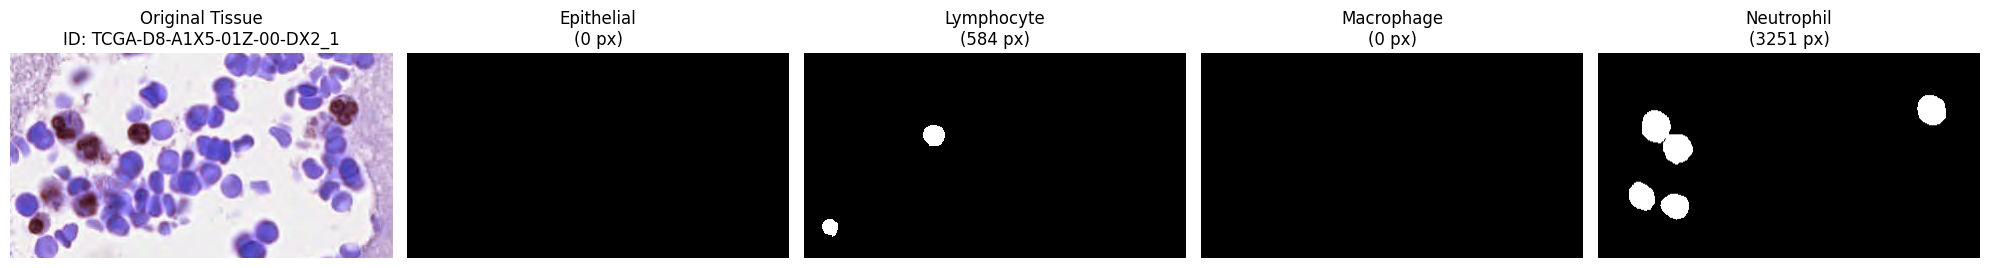

In [6]:
# Select a random sample
idx = np.random.randint(0, len(df))
sample = df.iloc[idx]

# Load original image
img = cv2.imread(sample['image_path'])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Load the mask stack using the function from Block 1
mask_stack = load_stacked_mask(sample['mask_dir'], img.shape)

plt.figure(figsize=(20, 6))

# Show Original
plt.subplot(1, 5, 1)
plt.imshow(img)
plt.title(f"Original Tissue\nID: {sample['image_id']}")
plt.axis('off')

# Show Channels
for i in range(4):
    plt.subplot(1, 5, i + 2)
    # vmin/vmax is the key to seeing the white cells
    plt.imshow(mask_stack[:, :, i], cmap='gray', vmin=0, vmax=1)

    pixel_count = np.sum(mask_stack[:, :, i])
    plt.title(f"{cell_types[i]}\n({int(pixel_count)} px)")
    plt.axis('off')

plt.tight_layout()
plt.show()

Commencing dataset audit...


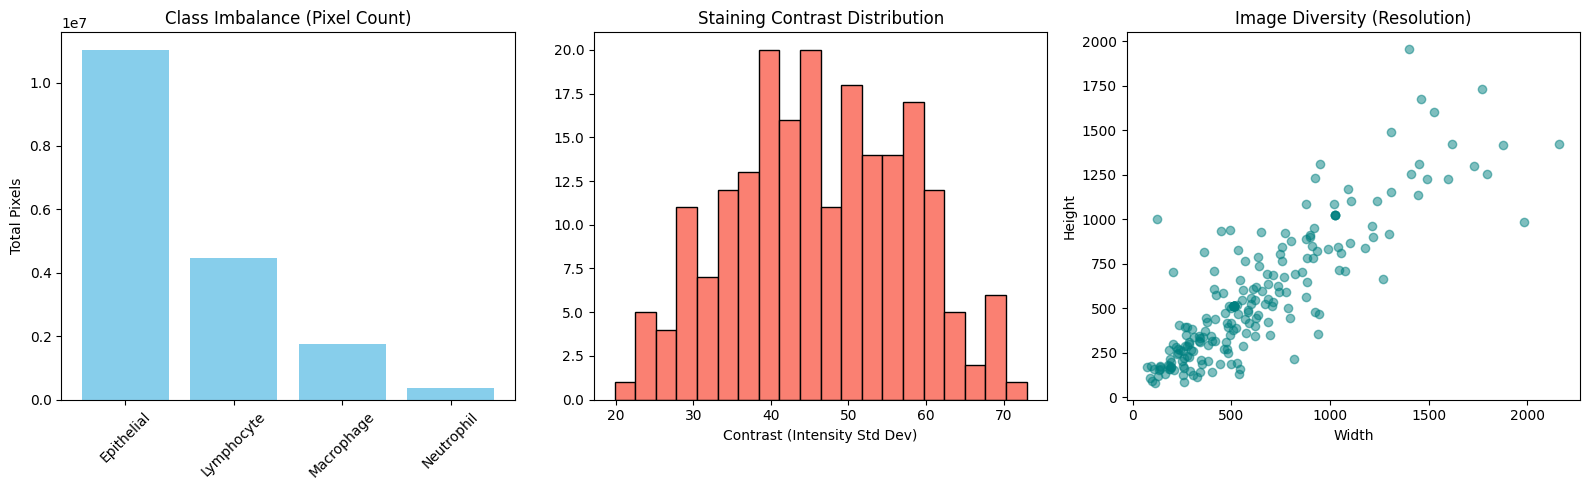


--- Summary Statistics ---
Epithelial: 11030389 pixels (10.9058% of total dataset area)
Lymphocyte: 4472162 pixels (4.4216% of total dataset area)
Macrophage: 1756508 pixels (1.7367% of total dataset area)
Neutrophil: 367597 pixels (0.3634% of total dataset area)


In [ ]:
# Initialize trackers for dataset characteristics
class_pixel_counts = {ctype: 0 for ctype in cell_types}
total_pixels = 0
brightness_values = []
contrast_values = []
image_shapes = []

print("Commencing dataset audit...")

for idx, row in df.iterrows():
    # Load original image
    img = cv2.imread(row['image_path'])
    if img is None: continue

    # Log dimensions and calculating contrast/brightness diversity
    image_shapes.append(img.shape[:2])
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness_values.append(np.mean(gray))
    contrast_values.append(gray.std())

    # Processing and analyzing class distribution
    mask = load_stacked_mask(row['mask_dir'], img.shape)
    for i, ctype in enumerate(cell_types):
        class_pixel_counts[ctype] += np.sum(mask[:, :, i])

    total_pixels += (img.shape[0] * img.shape[1])

# VISUALIZATION
plt.figure(figsize=(16, 5))

# Plot 1: Class Imbalance
plt.subplot(1, 3, 1)
plt.bar(class_pixel_counts.keys(), class_pixel_counts.values(), color='skyblue')
plt.title("Class Imbalance (Pixel Count)")
plt.xticks(rotation=45)
plt.ylabel("Total Pixels")

# Plot 2: Contrast Diversity
plt.subplot(1, 3, 2)
plt.hist(contrast_values, bins=20, color='salmon', edgecolor='black')
plt.title("Staining Contrast Distribution")
plt.xlabel("Contrast (Intensity Std Dev)")

# Plot 3: Image Resolution Diversity
plt.subplot(1, 3, 3)
widths = [s[1] for s in image_shapes]
heights = [s[0] for s in image_shapes]
plt.scatter(widths, heights, alpha=0.5, color='teal')
plt.title("Image Diversity (Resolution)")
plt.xlabel("Width")
plt.ylabel("Height")

plt.tight_layout()
plt.show()

# Print Detailed Summary
print("\n--- Summary Statistics ---")
for ctype, count in class_pixel_counts.items():
    area_percentage = (count / total_pixels) * 100
    print(f"{ctype}: {int(count)} pixels ({area_percentage:.4f}% of total dataset area)")

In [7]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

class MoNuSACDataset(torch.utils.data.Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = cv2.imread(row['image_path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # We reuse our working stacking function
        mask = load_stacked_mask(row['mask_dir'], image.shape)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Normalization and channel permutation for PyTorch
        image = image.float() / 255.0
        mask = mask.permute(2, 0, 1) # (H,W,4) -> (4,H,W)

        return image, mask

# Define transforms and split
IMAGE_SIZE = 256
train_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.HorizontalFlip(p=0.5),
    ToTensorV2(),
])

In [8]:
unique_patients = df['patient'].unique()
train_p, val_p = train_test_split(unique_patients, test_size=0.2, random_state=42)

train_df = df[df['patient'].isin(train_p)].reset_index(drop=True)
val_df = df[df['patient'].isin(val_p)].reset_index(drop=True)

train_loader = DataLoader(MoNuSACDataset(train_df, train_transforms),
                          batch_size=8,
                          shuffle=True,
                          num_workers=2,
                          pin_memory=True)

val_loader = DataLoader(MoNuSACDataset(val_df, A.Compose([A.Resize(256, 256), ToTensorV2()])),
                        batch_size=8,
                        num_workers=2,
                        pin_memory=True)

print(f"Batches in Train: {len(train_loader)} | Batches in Val: {len(val_loader)}")

Batches in Train: 22 | Batches in Val: 5


In [9]:
def conv_bn_relu(in_channels, out_channels, kernel_size=3, stride=1, padding=1):

    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
    )

def down_pooling():

    #Max pooling (2x2)

    return nn.MaxPool2d(2, stride=2)

def up_pooling(in_channels, out_channels, kernel_size=2, stride=2):

    #Transposed Convolution for upscaling

    return nn.Sequential(
        nn.ConvTranspose2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    )

class UNet(nn.Module):
    def __init__(self, input_channels, nclasses):
        super().__init__()

        # ENCODER (Contracting Path)

        self.conv1 = conv_bn_relu(input_channels, 16)
        self.conv2 = conv_bn_relu(16, 32)
        self.conv3 = conv_bn_relu(32, 64)
        self.conv4 = conv_bn_relu(64, 128)
        self.conv5 = conv_bn_relu(128, 256)

        self.down_pooling = down_pooling()

        # DECODER
        self.up_pool6 = up_pooling(256, 128)
        self.conv6 = conv_bn_relu(256, 128)

        self.up_pool7 = up_pooling(128, 64)
        self.conv7 = conv_bn_relu(128, 64)

        self.up_pool8 = up_pooling(64, 32)
        self.conv8 = conv_bn_relu(64, 32)

        self.up_pool9 = up_pooling(32, 16)
        self.conv9 = conv_bn_relu(32, 16)

        # Output layer: Maps 16 features to "nclasses" (4 channels)
        self.conv10 = nn.Conv2d(16, nclasses, 1)

    def forward(self, x):

        x1 = self.conv1(x)
        p1 = self.down_pooling(x1)

        x2 = self.conv2(p1)
        p2 = self.down_pooling(x2)

        x3 = self.conv3(p2)
        p3 = self.down_pooling(x3)

        x4 = self.conv4(p3)
        p4 = self.down_pooling(x4)

        x5 = self.conv5(p4)


        p6 = self.up_pool6(x5)

        x6 = torch.cat([p6, x4], dim=1)
        x6 = self.conv6(x6)

        p7 = self.up_pool7(x6)
        x7 = torch.cat([p7, x3], dim=1)
        x7 = self.conv7(x7)

        p8 = self.up_pool8(x7)
        x8 = torch.cat([p8, x2], dim=1)
        x8 = self.conv8(x8)

        p9 = self.up_pool9(x8)
        x9 = torch.cat([p9, x1], dim=1)
        x9 = self.conv9(x9)

        # Final Convolution
        output = self.conv10(x9)

        # Note: We return raw logits
        # No usage of Softmax, since it sums up the probability of the 4 channels
        # Loss function to be used in later codes BCEWithLogits

        return output

# INITIALIZATION
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3 Input Channels (RGB Image)
# 4 Output Classes (Epithelial, Lymphocyte, Macrophage, Neutrophil)
model = UNet(input_channels=3, nclasses=4).to(device)

print(f"Model initialized on {device}")

Model initialized on cpu


In [13]:
print("Checking batch shapes:")

# Get a batch from the train dataloader
for images, masks in train_loader:
    print(f"Train Dataloader - Images shape: {images.shape}")
    print(f"Train Dataloader - Masks shape: {masks.shape}")
    break

# Get a batch from the val dataloader
for images, masks in val_loader:
    print(f"Validation Dataloader - Images shape: {images.shape}")
    print(f"Validation Dataloader - Masks shape: {masks.shape}")
    break

Checking batch shapes:
Train Dataloader - Images shape: torch.Size([8, 3, 256, 256])
Train Dataloader - Masks shape: torch.Size([8, 4, 256, 256])
Validation Dataloader - Images shape: torch.Size([8, 3, 256, 256])
Validation Dataloader - Masks shape: torch.Size([8, 4, 256, 256])


In [10]:
def dice_score(pred, target):
    smooth = 1e-6
    # Flatten both tensors to ensure global spatial overlap calculation
    pred_flat = pred.view(-1)
    target_flat = target.view(-1)

    intersection = torch.sum(pred_flat * target_flat)
    return (2. * intersection + smooth) / (torch.sum(pred_flat) + torch.sum(target_flat) + smooth)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    dice_total = 0.0
    num_samples = 0

    # Lists to store flattened predictions for global F1 calculation
    all_labels_flat = []
    all_preds_flat = []

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass (Output is raw logits)
        outputs = model(inputs)

        # loss computation
        loss = criterion(outputs, labels)

        # Backward pass and update weights
        loss.backward()
        optimizer.step()

        # Update statistics
        running_loss += loss.item() * inputs.size(0)

        # Sigmoid and threshold to get binary prediction for Metrics
        outputs = torch.sigmoid(outputs)
        preds = (outputs > 0.5).float()

        # Calculate Dice for each image in batch
        for i in range(inputs.size(0)):
            dice_total += dice_score(preds[i], labels[i])

        # Collect data for F1
        all_labels_flat.extend(labels.cpu().numpy().ravel())
        all_preds_flat.extend(preds.cpu().numpy().ravel())

        num_samples += inputs.size(0)

    epoch_loss = running_loss / num_samples
    epoch_dice = (dice_total / num_samples).item() # Convert to scalar

    # Calculate Global F1 (Micro-averaged effectively by flattening)
    all_labels_flat = np.array(all_labels_flat)
    all_preds_flat = np.array(all_preds_flat)
    f1 = f1_score(all_labels_flat > 0, all_preds_flat > 0, average='binary')

    return epoch_loss, f1, epoch_dice

def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    dice_total = 0.0
    num_samples = 0
    all_labels_flat = []
    all_preds_flat = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)

            outputs = torch.sigmoid(outputs)
            preds = (outputs > 0.5).float()

            for i in range(inputs.size(0)):
                dice_total += dice_score(preds[i], labels[i])

            all_labels_flat.extend(labels.cpu().numpy().ravel())
            all_preds_flat.extend(preds.cpu().numpy().ravel())

            num_samples += inputs.size(0)

    epoch_loss = running_loss / num_samples
    epoch_dice = (dice_total / num_samples).item() # Convert to scalar

    all_labels_flat = np.array(all_labels_flat)
    all_preds_flat = np.array(all_preds_flat)
    f1 = f1_score(all_labels_flat > 0, all_preds_flat > 0, average='binary')

    return epoch_loss, f1, epoch_dice

In [11]:
import copy

def train_loop(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    best_f1 = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    # Dictionary to store history for graphing (for better visualization, and to detect any type of overfitting)
    history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': [],
        'train_dice': [], 'val_dice': []
    }

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')

        # TRAINING
        train_loss, train_f1, train_dice = train_one_epoch(model, train_loader, criterion, optimizer, device)
        history['train_loss'].append(train_loss)
        history['train_f1'].append(train_f1)
        history['train_dice'].append(train_dice)
        print(f'Training Loss: {train_loss:.4f}, F1: {train_f1:.4f}, Dice: {train_dice:.4f}')

        # VALIDATION
        val_loss, val_f1, val_dice = validate_one_epoch(model, val_loader, criterion, device)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_dice'].append(val_dice)
        print(f'Validation Loss: {val_loss:.4f}, F1: {val_f1:.4f}, Dice: {val_dice:.4f}')

        # Save Best Model
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_model_wts = copy.deepcopy(model.state_dict())
            print('Best model updated!')

    print(f'Best model F1 score: {best_f1:.4f}')
    model.load_state_dict(best_model_wts)
    return model, history

In [13]:
!pip install torch
import torch
print("Dispositivo:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Dispositivo: CPU


Epoch 1/50
Training Loss: 0.7282, F1: 0.0761, Dice: 0.0770
Validation Loss: 0.7228, F1: 0.0669, Dice: 0.0663
Best model updated!
Epoch 2/50
Training Loss: 0.6949, F1: 0.0774, Dice: 0.0763
Validation Loss: 0.6785, F1: 0.0703, Dice: 0.0695
Best model updated!
Epoch 3/50
Training Loss: 0.6674, F1: 0.0842, Dice: 0.0806
Validation Loss: 0.6493, F1: 0.0819, Dice: 0.0776
Best model updated!
Epoch 4/50
Training Loss: 0.6471, F1: 0.0935, Dice: 0.0860
Validation Loss: 0.7780, F1: 0.0895, Dice: 0.0783
Best model updated!
Epoch 5/50
Training Loss: 0.6340, F1: 0.1028, Dice: 0.0926
Validation Loss: 0.6235, F1: 0.1026, Dice: 0.0914
Best model updated!
Epoch 6/50
Training Loss: 0.6262, F1: 0.1087, Dice: 0.0970
Validation Loss: 0.6571, F1: 0.1041, Dice: 0.0870
Best model updated!
Epoch 7/50
Training Loss: 0.6131, F1: 0.1172, Dice: 0.1034
Validation Loss: 0.6058, F1: 0.1159, Dice: 0.1024
Best model updated!
Epoch 8/50
Training Loss: 0.6041, F1: 0.1206, Dice: 0.1074
Validation Loss: 0.5948, F1: 0.1271, D

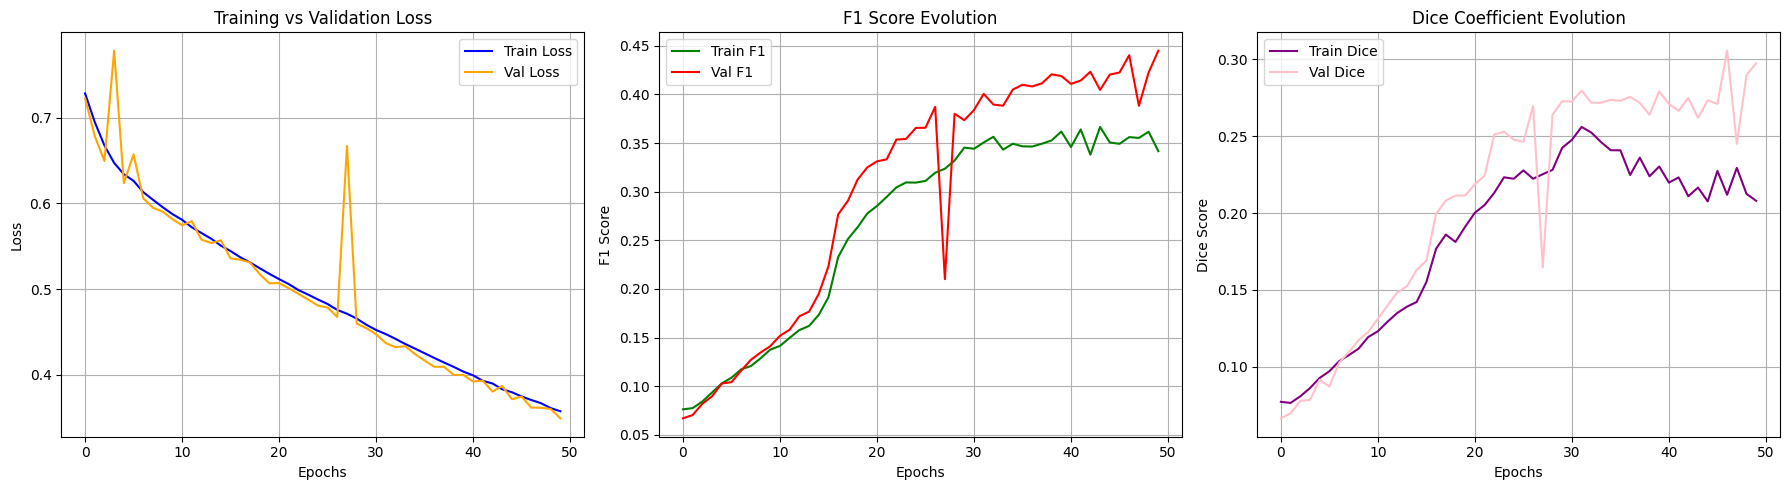

Model saved successfully.


In [29]:
import torch.optim as optim

# Hyperparameters & Setup
# BCEWithLogitsLoss since sigmoid was not implemented in the U-NET
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
NUM_EPOCHS = 50  # Can be increased to 30 or 50 later

# Run Training
trained_model, history = train_loop(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    NUM_EPOCHS,
    device
)

#Plotting the Results
plt.figure(figsize=(18, 5))

# Plot Loss
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue')
plt.plot(history['val_loss'], label='Val Loss', color='orange')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot F1 Score
plt.subplot(1, 3, 2)
plt.plot(history['train_f1'], label='Train F1', color='green')
plt.plot(history['val_f1'], label='Val F1', color='red')
plt.title('F1 Score Evolution')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

# Plot Dice Coefficient
plt.subplot(1, 3, 3)
plt.plot(history['train_dice'], label='Train Dice', color='purple')
plt.plot(history['val_dice'], label='Val Dice', color='pink')
plt.title('Dice Coefficient Evolution')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Saving the final model
torch.save(trained_model.state_dict(), 'monusac_unet_best.pth')
print("Model saved successfully.")

In [30]:
#to save the model
torch.save(trained_model.state_dict(), 'monusac_unet_best.pth')
print("Model weights saved successfully.")

Model weights saved successfully.


In [31]:
from google.colab import files
files.download('monusac_unet_best.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
import shutil
# This copies the file from the temporary Colab folder to your permanent Drive
shutil.copy('monusac_unet_best.pth', '/content/drive/MyDrive/monusac_unet_best.pth')
print("Model backed up to Google Drive successfully.")

Model backed up to Google Drive successfully.


In [15]:
import torch

device = torch.device('cpu')
# Create the architecture shell again
model = UNet(input_channels=3, nclasses=4)

# Load the saved weights and map them to the CPU
model.load_state_dict(torch.load('/content/drive/MyDrive/monusac_unet_best.pth', map_location=device))
model.eval() # Set to evaluation mode
model.to(device)

print("Model is loaded on CPU and ready for final testing!")

Model is loaded on CPU and ready for final testing!


In [19]:
count = 0
test_data_path = '/content/drive/MyDrive/MoNuSAC_testing_data_and_annotations'
test_destination_path = '/content/drive/MyDrive/'

if not os.path.exists(test_destination_path):
    os.makedirs(test_destination_path)

os.chdir(test_destination_path)

test_mask_folder = os.path.join(test_destination_path, 'MoNuSAC_test_masks')

try:
    if not os.path.exists(test_mask_folder):
        os.mkdir(test_mask_folder)
        print("Successfully created the directory: MoNuSAC_test_masks")
    else:
        print("Directory MoNuSAC_test_masks already exists")
except OSError as e:
    print(f"Creation of the mask directory failed: {e}")

os.chdir(test_mask_folder)
test_patients = [x[0] for x in os.walk(test_data_path)] # Total patients in the test_data_path

print(f"Total patient folders found: {len(test_patients)}")

Successfully created the directory: MoNuSAC_test_masks
Total patient folders found: 26


In [22]:
test_count = 0

# The base directory where masks will be stored
os.chdir(test_mask_folder)

for test_patient_loc in test_patients:
    # Extract patient name using the same slicing logic
    test_patient_name = test_patient_loc[len(test_data_path)+1:]
    print(test_patient_name)

    ## Creating patient directory in the test destination folder
    try:
        os.mkdir(test_patient_name)
    except OSError:
        print("\n Creation of the patient's directory %s failed" % test_patient_name)

    ## Reading sub-images (SVS) for each test patient
    test_sub_images = glob(test_patient_loc + '/*.svs')
    for test_sub_image_loc in test_sub_images:
        test_sub_image_name = test_sub_image_loc[len(test_data_path) + len(test_patient_name) + 2:-4]
        print(test_sub_image_name)

        # Creating sub-image directory under the patient folder
        test_sub_image_path = './' + test_patient_name + '/' + test_sub_image_name
        try:
            os.mkdir(test_sub_image_path)
        except OSError:
            print("\n Creation of the sub-image directory %s failed" % test_sub_image_path)

        test_image_name = test_sub_image_loc
        test_img = openslide.OpenSlide(test_image_name)


        cv2.imwrite(test_sub_image_loc[:-4] + '.tif', np.array(test_img.read_region((0,0), 0, test_img.level_dimensions[0])))


        test_xml_file_name = test_image_name[:-4] + '.xml'
        if not os.path.exists(test_xml_file_name):
            continue

        test_tree = ET.parse(test_xml_file_name)
        test_root = test_tree.getroot()

        # Generating binary masks for each cell-type (including Ambiguous)
        for k in range(len(test_root)):
            test_label = [x.attrib['Name'] for x in test_root[k][0]]
            test_label = test_label[0]

            for child in test_root[k]:
                for x in child:
                    test_r = x.tag
                    if test_r == 'Attribute':
                        test_count = test_count + 1
                        print(test_count)
                        test_label = x.attrib['Name']
                        # Initializing mask based on image dimensions
                        test_binary_mask = np.transpose(np.zeros((test_img.read_region((0,0), 0, test_img.level_dimensions[0]).size)))
                        print(test_label)

                        # Creating folder for the specific cell type/label
                        test_sub_path = test_sub_image_path + '/' + test_label

                        try:
                            os.mkdir(test_sub_path)
                        except OSError:
                            print("Creation of the directory %s failed" % test_label)
                        else:
                            print("Successfully created the directory %s " % test_label)

                    if test_r == 'Region':
                        test_regions = []
                        test_vertices = x[1]
                        test_coords = np.zeros((len(test_vertices), 2))
                        for i, vertex in enumerate(test_vertices):
                            test_coords[i][0] = vertex.attrib['X']
                            test_coords[i][1] = vertex.attrib['Y']
                        test_regions.append(test_coords)

                        test_vertex_row_coords = test_regions[0][:,0]
                        test_vertex_col_coords = test_regions[0][:,1]


                        test_fill_row_coords, test_fill_col_coords = draw.polygon(test_vertex_col_coords, test_vertex_row_coords, test_binary_mask.shape)
                        test_binary_mask[test_fill_row_coords, test_fill_col_coords] = 255


                        test_mask_save_path = test_sub_path + '/' + str(test_count) + '_mask.tif'
                        cv2.imwrite(test_mask_save_path, test_binary_mask)



 Creation of the patient's directory  failed
TCGA-MP-A4T7-01Z-00-DX1
TCGA-MP-A4T7-01Z-00-DX1_001
1
Epithelial
Successfully created the directory Epithelial 
2
Lymphocyte
Successfully created the directory Lymphocyte 
3
Neutrophil
Successfully created the directory Neutrophil 
4
Macrophage
Successfully created the directory Macrophage 
5
Ambiguous
Successfully created the directory Ambiguous 
TCGA-MP-A4T7-01Z-00-DX1_002
6
Epithelial
Successfully created the directory Epithelial 
7
Lymphocyte
Successfully created the directory Lymphocyte 
8
Neutrophil
Successfully created the directory Neutrophil 
9
Macrophage
Successfully created the directory Macrophage 
10
Ambiguous
Successfully created the directory Ambiguous 
TCGA-MP-A4T7-01Z-00-DX1_003
11
Epithelial
Successfully created the directory Epithelial 
12
Lymphocyte
Successfully created the directory Lymphocyte 
13
Neutrophil
Successfully created the directory Neutrophil 
14
Macrophage
Successfully created the directory Macrophage 
15
A

In [25]:
test_image_data = []

for test_patient_name in os.listdir(test_mask_folder):
    test_patient_mask_path = os.path.join(test_mask_folder, test_patient_name)
    test_patient_src_path = os.path.join(test_data_path, test_patient_name)


    if os.path.isdir(test_patient_mask_path):
        for test_sub_image_name in os.listdir(test_patient_mask_path):
            test_sub_image_dir = os.path.join(test_patient_mask_path, test_sub_image_name)


            test_img_file = os.path.join(test_patient_src_path, test_sub_image_name + '.tif')


            if os.path.exists(test_img_file):
                test_image_data.append({
                    'image_path': test_img_file,
                    'mask_dir': test_sub_image_dir,
                    'patient': test_patient_name,
                    'image_id': test_sub_image_name
                })
            else:
                print(f"Warning: .tif image not found for {test_sub_image_name} at {test_img_file}")


test_df = pd.DataFrame(test_image_data)

if test_df.empty:
    print("Error: DataFrame is empty. Please check if the .tif files were saved correctly in the source paths.")
else:
    print(f"Success! Test DataFrame created with {len(test_df)} entries.")
    print(test_df.head())

Success! Test DataFrame created with 101 entries.
                                          image_path  \
0  /content/drive/MyDrive/MoNuSAC_testing_data_an...   
1  /content/drive/MyDrive/MoNuSAC_testing_data_an...   
2  /content/drive/MyDrive/MoNuSAC_testing_data_an...   
3  /content/drive/MyDrive/MoNuSAC_testing_data_an...   
4  /content/drive/MyDrive/MoNuSAC_testing_data_an...   

                                            mask_dir                  patient  \
0  /content/drive/MyDrive/MoNuSAC_test_masks/TCGA...  TCGA-MP-A4T7-01Z-00-DX1   
1  /content/drive/MyDrive/MoNuSAC_test_masks/TCGA...  TCGA-MP-A4T7-01Z-00-DX1   
2  /content/drive/MyDrive/MoNuSAC_test_masks/TCGA...  TCGA-MP-A4T7-01Z-00-DX1   
3  /content/drive/MyDrive/MoNuSAC_test_masks/TCGA...  TCGA-MP-A4T7-01Z-00-DX1   
4  /content/drive/MyDrive/MoNuSAC_test_masks/TCGA...  TCGA-MP-A4T7-01Z-00-DX1   

                      image_id  
0  TCGA-MP-A4T7-01Z-00-DX1_001  
1  TCGA-MP-A4T7-01Z-00-DX1_002  
2  TCGA-MP-A4T7-01Z-00-DX1_

In [31]:
# Define transforms for the test set (same as validation)
test_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    ToTensorV2(),
])

test_dataset = MoNuSACDataset(test_df, test_transforms)
test_loader = DataLoader(test_dataset,
                         batch_size=8,
                         shuffle=False, # No need to shuffle test data
                         num_workers=2,
                         pin_memory=True)

print(f"Batches in Test: {len(test_loader)}")

model.eval()
images, ground_truths, predictions = [], [], []
num_images = min(8, len(test_df))

with torch.no_grad():
    for i, (inputs, labels) in enumerate(test_loader):
        if i >= num_images: break

        inputs = inputs.to(device)
        outputs = model(inputs)
        outputs = torch.sigmoid(outputs)
        preds = (outputs > 0.4).float()

        images.append(inputs.cpu().numpy())
        ground_truths.append(labels.cpu().numpy())
        predictions.append(preds.cpu().numpy())

fig, axes = plt.subplots(num_images, 3, figsize=(15, num_images * 5))

for i in range(num_images):
    # Column 1: Original Image
    ax0 = axes[i, 0]
    ax0.imshow(images[i][0].transpose(1, 2, 0))
    ax0.set_title(f'Test: {test_df.iloc[i]["image_id"]}')
    ax0.axis('off')

    # Column 2: Ground Truth (Collapsing 4 channels into 1 for visibility)
    ax1 = axes[i, 1]
    gt_viz = ground_truths[i][0].sum(axis=0)
    ax1.imshow(gt_viz, cmap='gray')
    ax1.set_title('Combined Ground Truth')
    ax1.axis('off')

    # Column 3: Model Prediction (Collapsing 4 channels into 1)
    ax2 = axes[i, 2]
    pred_viz = predictions[i][0].sum(axis=0)
    ax2.imshow(pred_viz, cmap='gray')
    ax2.set_title('Model Prediction')
    ax2.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

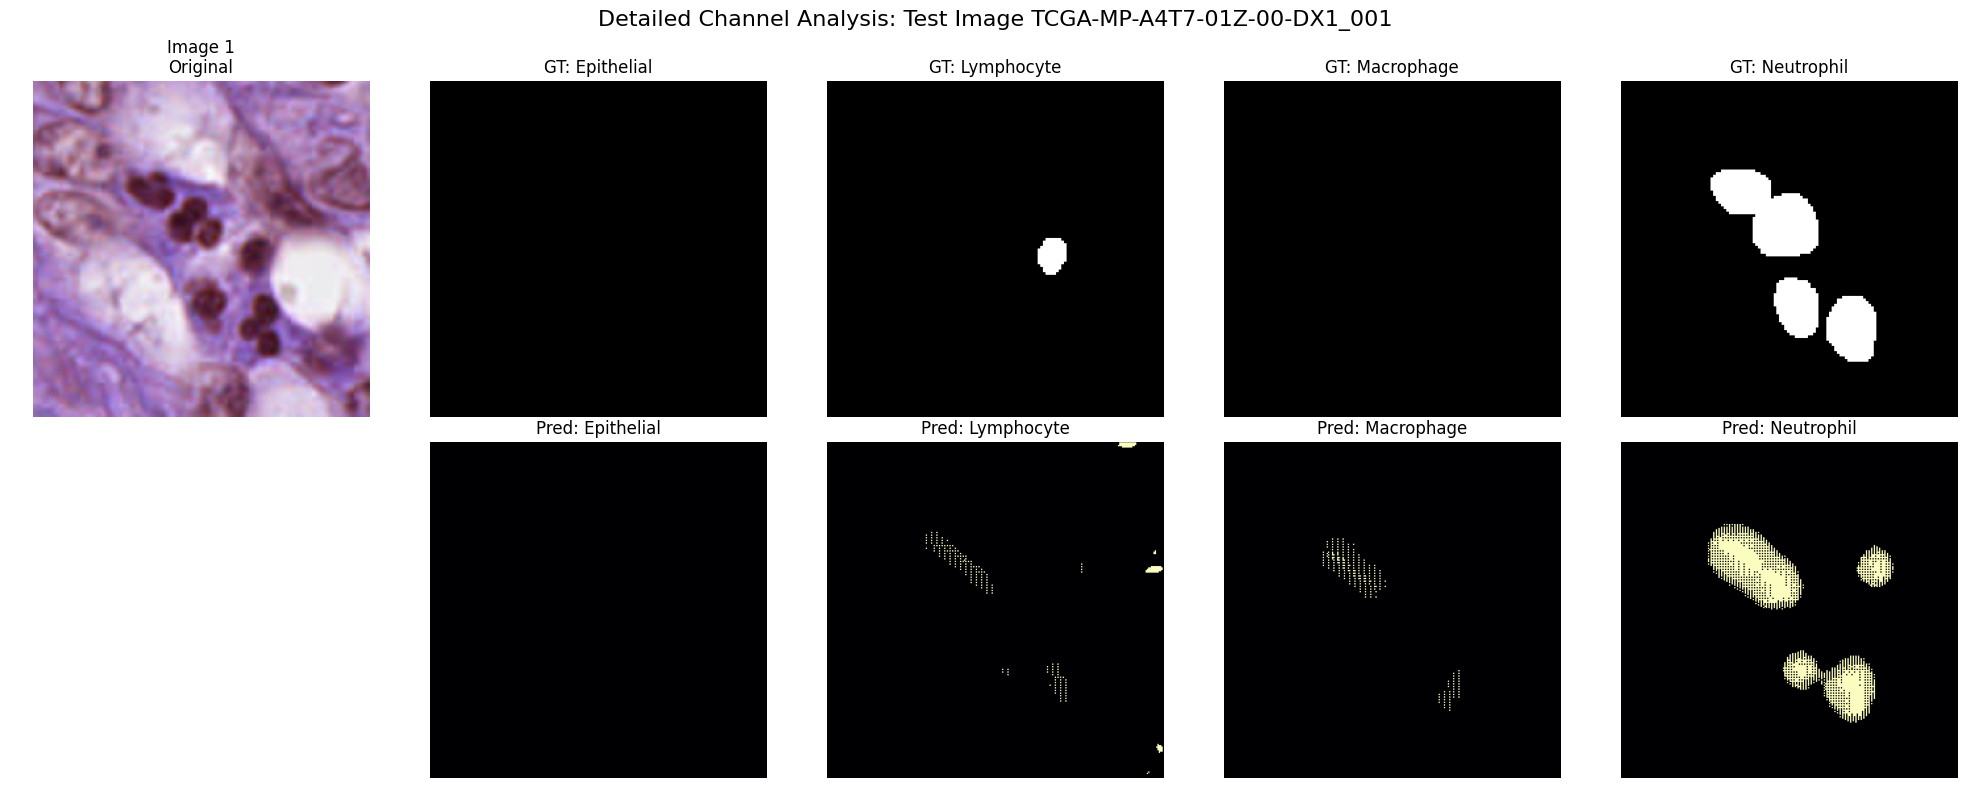

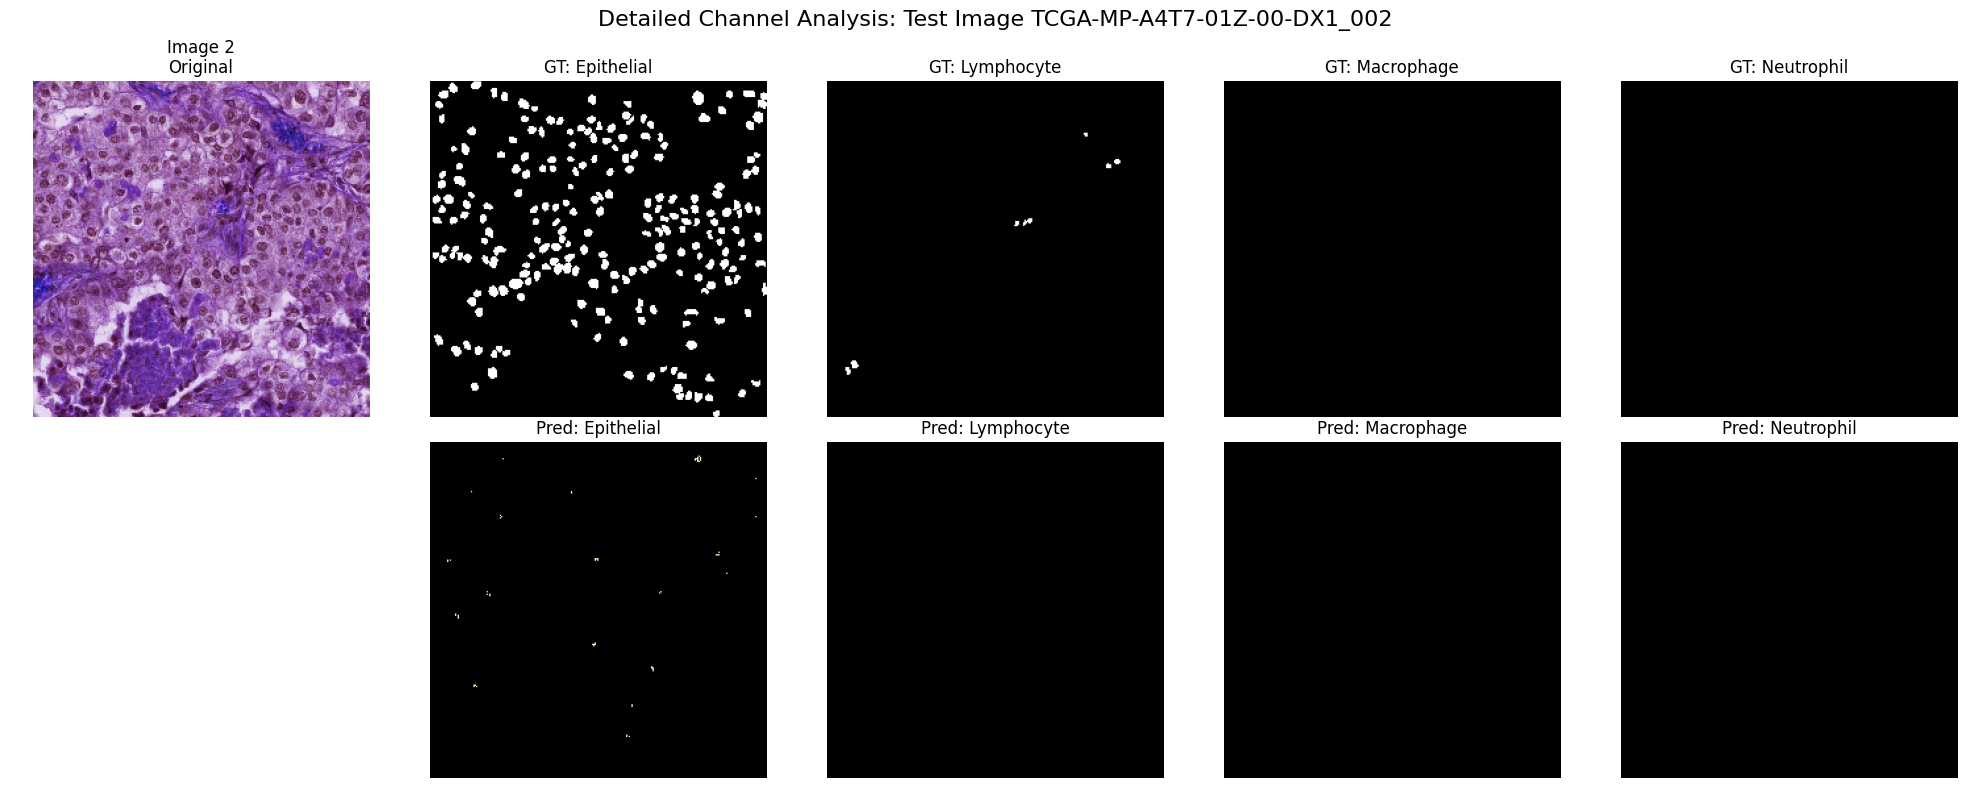

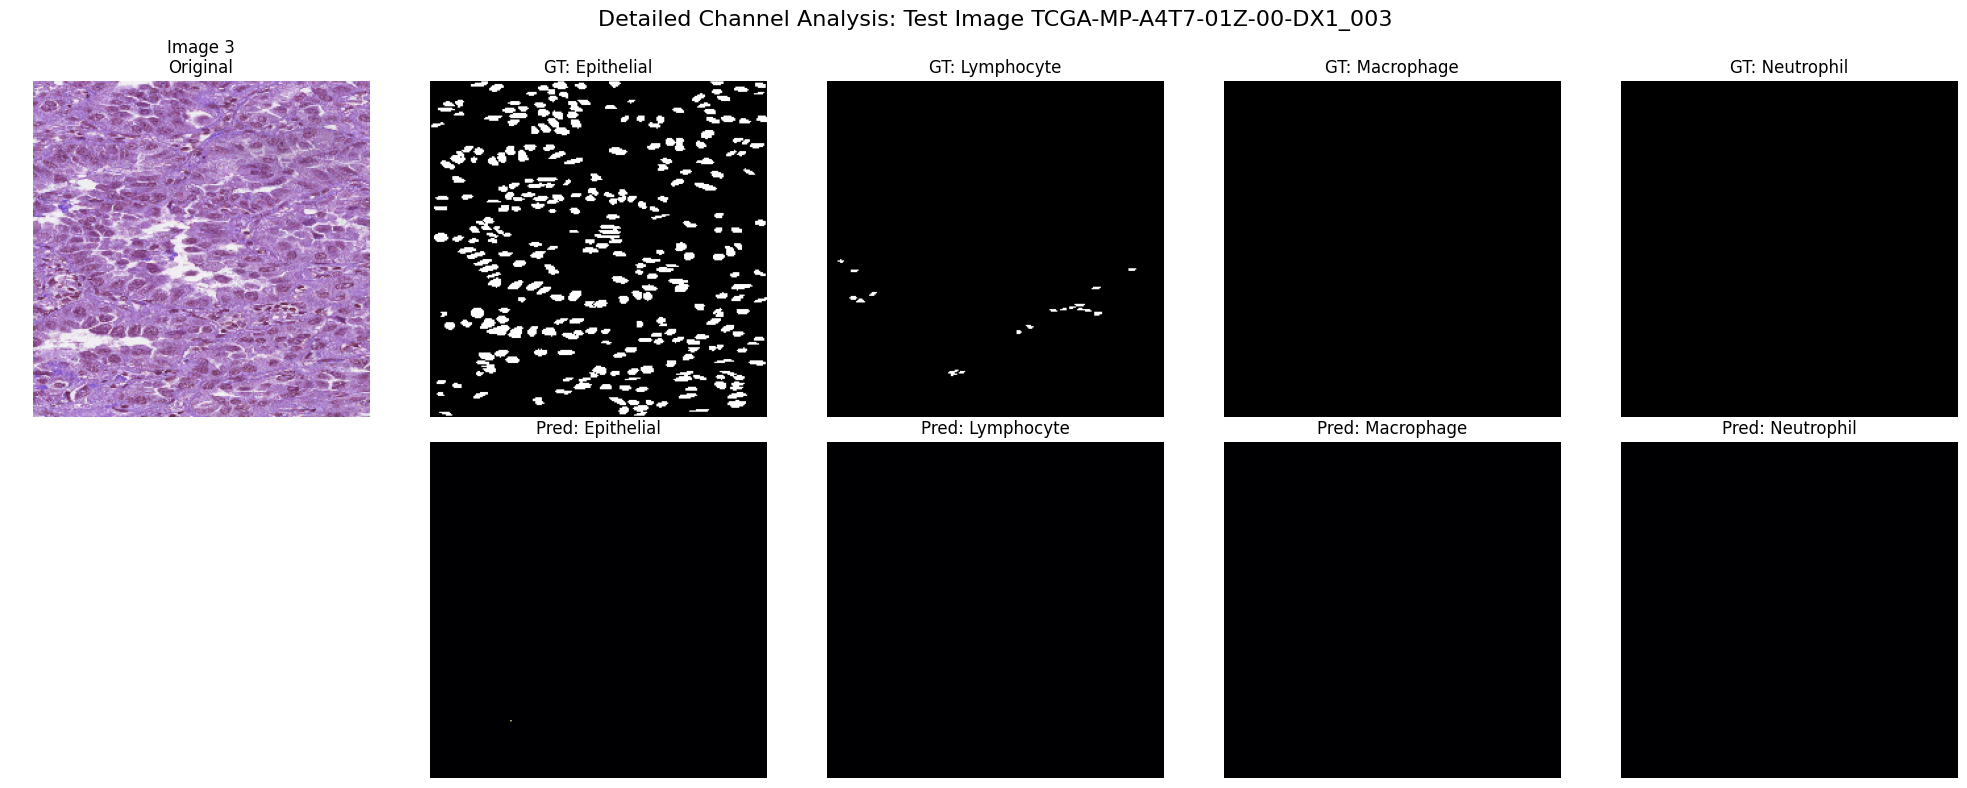

In [34]:
model.eval()
num_samples = 3 # We'll look at 3 images deeply rather than 8 shallowly
cell_types = ['Epithelial', 'Lymphocyte', 'Macrophage', 'Neutrophil']

with torch.no_grad():
    for i, (inputs, labels) in enumerate(test_loader):
        if i >= num_samples: break

        inputs = inputs.to(device)
        outputs = model(inputs)
        outputs = torch.sigmoid(outputs)
        preds = (outputs > 0.55).float() # You can experiment with 0.3 or 0.4 here

        # Convert to numpy for plotting
        img_np = inputs[0].cpu().numpy().transpose(1, 2, 0)
        gt_np = labels[0].cpu().numpy()
        pred_np = preds[0].cpu().numpy()

        # Create a large grid: 2 rows (GT and Pred) x 5 columns (Original + 4 Channels)
        fig, axes = plt.subplots(2, 5, figsize=(20, 8))

        # Row 0: Ground Truths
        axes[0, 0].imshow(img_np)
        axes[0, 0].set_title(f"Image {i+1}\nOriginal")
        axes[0, 0].axis('off')

        for c in range(4):
            axes[0, c+1].imshow(gt_np[c], cmap='gray', vmin=0, vmax=1)
            axes[0, c+1].set_title(f"GT: {cell_types[c]}")
            axes[0, c+1].axis('off')

        # Row 1: Predictions
        axes[1, 0].axis('off') # Leave blank or show original again
        for c in range(4):
            axes[1, c+1].imshow(pred_np[c], cmap='magma', vmin=0, vmax=1)
            axes[1, c+1].set_title(f"Pred: {cell_types[c]}")
            axes[1, c+1].axis('off')

        plt.suptitle(f"Detailed Channel Analysis: Test Image {test_df.iloc[i]['image_id']}", fontsize=16)
        plt.tight_layout()
        plt.show()